1) Leitura da base
Dimensão da base: (60, 3)

--- Primeiras 10 linhas (visão inicial) ---
   Janela  CPU_medio_pct  Tempo_resposta_ms
0       1          50.68             179.33
1       2          41.07             138.25
2       3          58.12             188.35
3       4          54.87             178.87
4       5          69.50             191.41
5       6          57.98             172.28
6       7          46.70             169.76
7       8          39.04             132.26
8       9          61.13             196.49
9      10          51.82             170.54

2) Exploração inicial


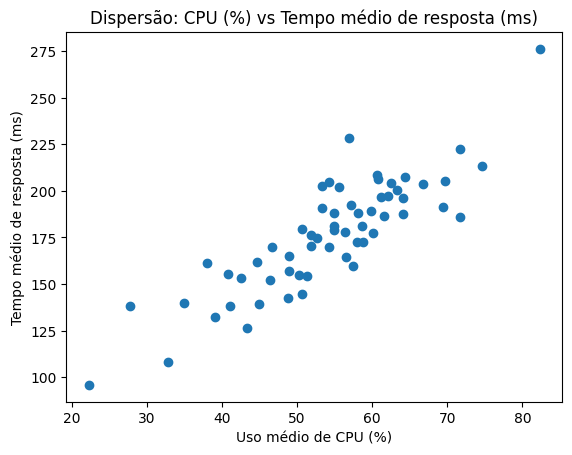


--- Correlação de Pearson (exploração inicial) ---
r = 0.858165
p-valor = 1.938047e-18
Conclusão: há evidência de correlação linear na amostra (rejeita H0: ρ=0).
Observação: correlação NÃO implica causalidade.

3) Ajuste do modelo (MQO)

--- Saída padrão do modelo (statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:      Tempo_resposta_ms   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     162.1
Date:                Fri, 30 Jan 2026   Prob (F-statistic):           1.94e-18
Time:                        17:10:32   Log-Likelihood:                -249.33
No. Observations:                  60   AIC:                             502.7
Df Residuals:                      58   BIC:                             506.9
Df Model:                           1                                         
Covar

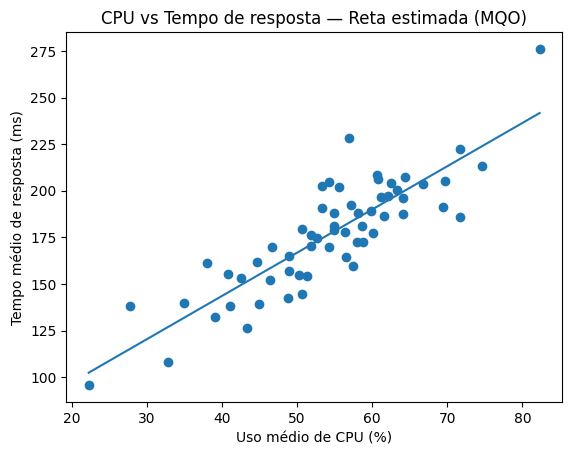


3.1) Testes t para os coeficientes (H0: coeficiente = 0)

β0 (intercepto)
Estimativa = 50.780690
Erro-padrão = 10.093736
t = 5.031
p-valor = 5.022965e-06
Conclusão (α=0.05): rejeita H0 → coeficiente estatisticamente diferente de 0.

β1 (inclinação)
Estimativa = 2.319656
Erro-padrão = 0.182210
t = 12.731
p-valor = 1.938047e-18
Conclusão (α=0.05): rejeita H0 → coeficiente estatisticamente diferente de 0.

--- Tabela ilustrativa: 15 primeiras observações (X, Y, Ŷ, resíduo) ---
    CPU_medio_pct  Tempo_resposta_ms    y_hat   resid
0           50.68             179.33  168.341  10.989
1           41.07             138.25  146.049  -7.799
2           58.12             188.35  185.599   2.751
3           54.87             178.87  178.060   0.810
4           69.50             191.41  211.997 -20.587
5           57.98             172.28  185.274 -12.994
6           46.70             169.76  159.109  10.651
7           39.04             132.26  141.340  -9.080
8           61.13             196.

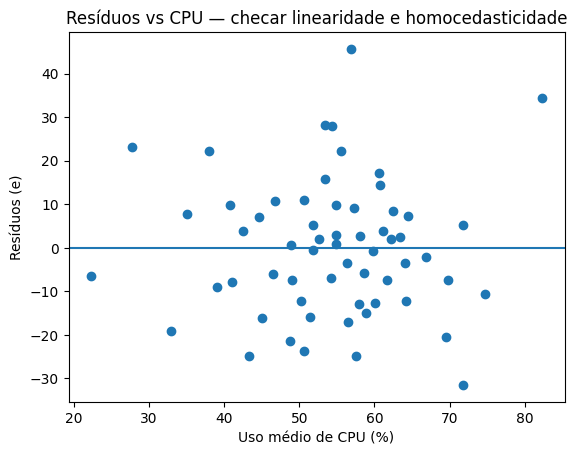

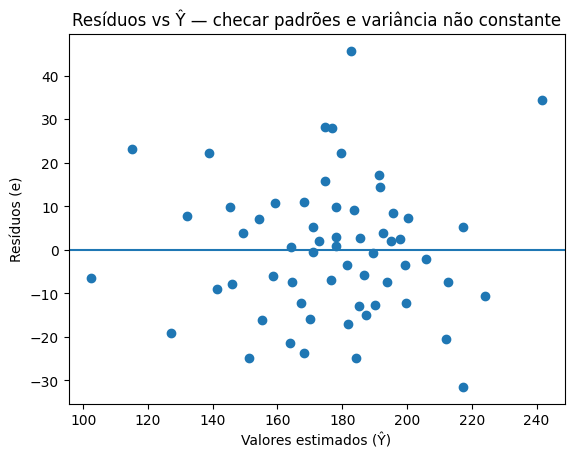


5) Resíduos padronizados / studentizados e influência
--- Resumo (primeiras 10 observações) ---
   CPU_medio_pct  Tempo_resposta_ms  resid_padronizado  resid_studentizado    cook_d
0          50.68             179.33           0.700040            0.703487  0.004679
1          41.07             138.25          -0.496816           -0.503824  0.005376
2          58.12             188.35           0.175240            0.175415  0.000298
3          54.87             178.87           0.051586            0.051573  0.000023
4          69.50             191.41          -1.311436           -1.353648  0.045466
5          57.98             172.28          -0.827777           -0.833347  0.006588
6          46.70             169.76           0.678523            0.683789  0.005897
7          39.04             132.26          -0.578426           -0.589456  0.008842
8          61.13             196.49           0.248998            0.249869  0.000747
9          51.82             170.54          -0.02836

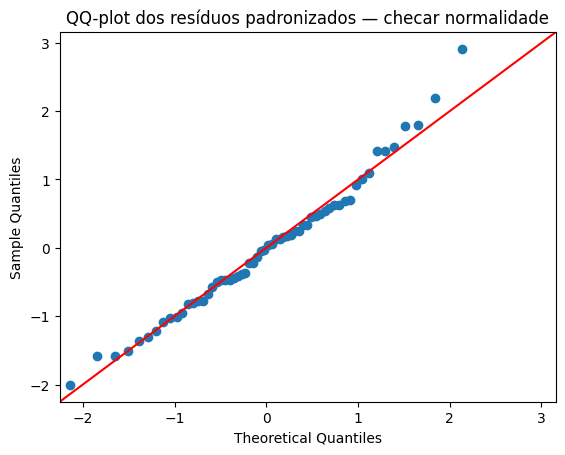


6) Testes formais 

--- Teste de Shapiro–Wilk (normalidade dos resíduos) ---
Estatística W = 0.982026
p-valor       = 5.199824e-01
Conclusão: normalidade dos resíduos é plausível (não rejeita H0).

--- Teste de Anderson–Darling (normalidade dos resíduos) ---
Estatística A² = 0.280205

Valores críticos:
  α = 15.0%  | valor crítico = 0.544000
  α = 10.0%  | valor crítico = 0.619000
  α = 5.0%  | valor crítico = 0.743000
  α = 2.5%  | valor crítico = 0.866000
  α = 1.0%  | valor crítico = 1.030000

Decisão para α = 5.0%:
Conclusão: normalidade dos resíduos é plausível (não rejeita H0).

--- Teste de Breusch–Pagan (heterocedasticidade) ---
Estatística LM  = 0.627487
p-valor (LM)    = 0.428279
Estatística F   = 0.612981
p-valor (F)     = 0.436853
Conclusão: não há evidência de heterocedasticidade (não rejeita H0).

--- Durbin–Watson (autocorrelação de 1ª ordem) — diagnóstico ---
DW = 2.412156
Direção sugerida: autocorrelação negativa.
Leitura rápida: fraca ou inexistente (DW próximo de 2)

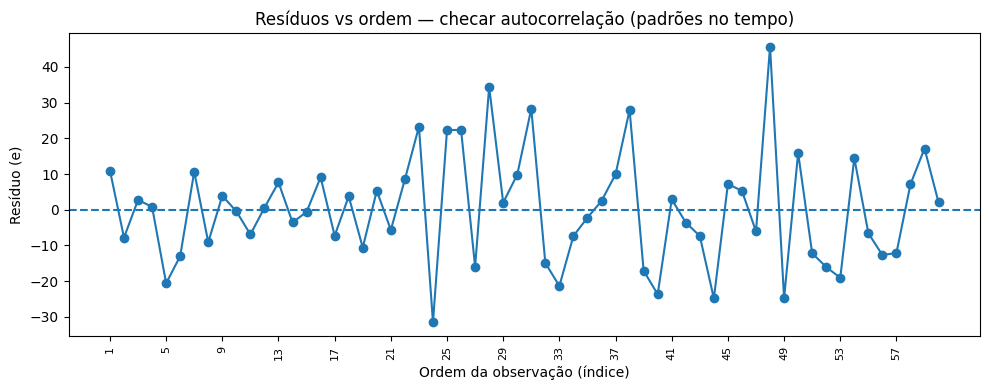


8) Gráfico da Distância de Cook


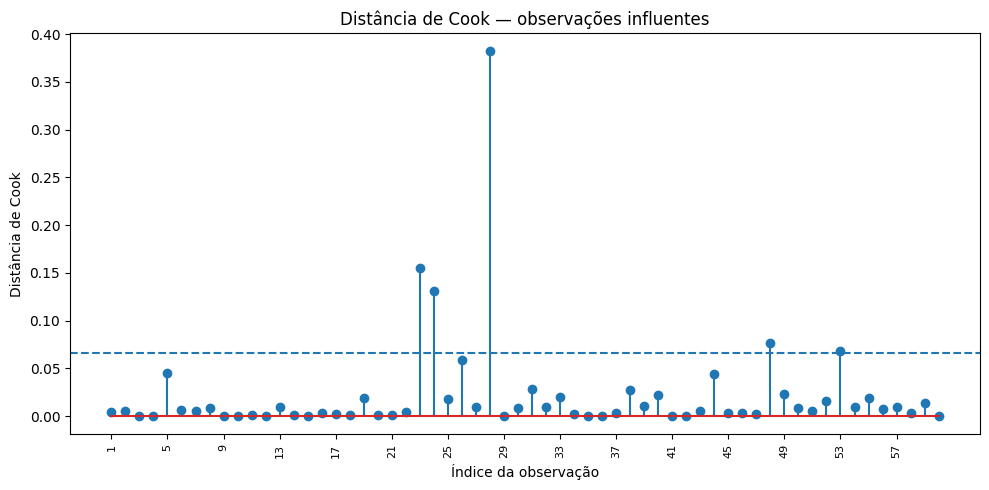


==================== CONCLUSÕES DIDÁTICAS ====================
1) A regressão estima a tendência média (sinal) e aceita que há ruído (resíduos).
2) β1 indica o aumento médio de latência (ms) para cada +1% de CPU.
3) Resíduos são o centro do diagnóstico: procuram padrões, funil, autocorrelação e outliers.
4) Distância de Cook mede influência: ponto influente pode mudar o modelo mesmo com resíduo pequeno.


In [3]:
# ============================================================
# REGRESSÃO LINEAR SIMPLES (MQO) — EXEMPLO: CPU (%) vs Latência (ms)
# Script didático com análise completa
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.stats.api as sms

from scipy.stats import pearsonr, shapiro

# ------------------------------------------------------------
# 0) Configurações de exibição (melhorar leitura no console)
# ------------------------------------------------------------
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

ALPHA = 0.05

# ------------------------------------------------------------
# 1) Ler a base de dados
# ------------------------------------------------------------
# No Colab, suba o arquivo para a pasta /content.
# Arquivo: exemplo_regressao_CPU_tempo_resposta.csv
df = pd.read_csv("/content/exemplo_regressao_CPU_tempo_resposta.csv")

print("============================================================")
print("1) Leitura da base")
print("============================================================")
print("Dimensão da base:", df.shape)
print("\n--- Primeiras 10 linhas (visão inicial) ---")
print(df.head(10))

# Definição das variáveis
X = df["CPU_medio_pct"]       # variável explicativa (contínua)
y = df["Tempo_resposta_ms"]   # variável resposta (contínua)

# ------------------------------------------------------------
# 2) Exploração inicial: diagrama de dispersão
# ------------------------------------------------------------
print("\n============================================================")
print("2) Exploração inicial")
print("============================================================")

plt.figure()
plt.scatter(X, y)
plt.xlabel("Uso médio de CPU (%)")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("Dispersão: CPU (%) vs Tempo médio de resposta (ms)")
plt.show()

# ------------------------------------------------------------
# 3) Associação linear: correlação de Pearson (formatado)
# ------------------------------------------------------------
r, pvalor = pearsonr(X, y)

print("\n--- Correlação de Pearson (exploração inicial) ---")
print(f"r = {r:.6f}")
print(f"p-valor = {pvalor:.6e}")

if pvalor <= ALPHA:
    print("Conclusão: há evidência de correlação linear na amostra (rejeita H0: ρ=0).")
else:
    print("Conclusão: não há evidência de correlação linear na amostra (não rejeita H0: ρ=0).")

print("Observação: correlação NÃO implica causalidade.\n")

# ------------------------------------------------------------
# 4) Ajuste do modelo: Regressão linear simples por MQO
# ------------------------------------------------------------
print("============================================================")
print("3) Ajuste do modelo (MQO)")
print("============================================================")

# statsmodels exige intercepto explicitamente:
X_design = sm.add_constant(X)  # cria coluna "const" (β0)
modelo = sm.OLS(y, X_design).fit()

print("\n--- Saída padrão do modelo (statsmodels) ---")
print(modelo.summary())

# ------------------------------------------------------------
# 5) Extraindo coeficientes e interpretando (β0 e β1)
# ------------------------------------------------------------
beta0_hat = float(modelo.params["const"])
beta1_hat = float(modelo.params["CPU_medio_pct"])

print("\n--- Estimadores MQO ---")
print(f"β0 (intercepto) estimado = {beta0_hat:.6f}")
print(f"β1 (inclinação) estimado = {beta1_hat:.6f}")

print("\nInterpretação (Observabilidade):")
print("- β1: aumento médio no tempo de resposta (ms) associado a +1 ponto percentual de CPU.")
print("- β0: tempo esperado quando CPU=0% (pode ser extrapolação; interpretar com cautela).")

# ------------------------------------------------------------
# 6) Dispersão + reta estimada
# ------------------------------------------------------------
plt.figure()
plt.scatter(X, y)

x_line = np.linspace(float(X.min()), float(X.max()), 200)
y_line = beta0_hat + beta1_hat * x_line

plt.plot(x_line, y_line)
plt.xlabel("Uso médio de CPU (%)")
plt.ylabel("Tempo médio de resposta (ms)")
plt.title("CPU vs Tempo de resposta — Reta estimada (MQO)")
plt.show()

# ------------------------------------------------------------
# 7) Testes t para os coeficientes da regressão (saída formatada)
#
# Para cada coeficiente βj:
#   H0: βj = 0  (sem efeito linear)
#   H1: βj ≠ 0  (efeito linear diferente de zero)
# ------------------------------------------------------------
print("\n============================================================")
print("3.1) Testes t para os coeficientes (H0: coeficiente = 0)")
print("============================================================")

for nome in modelo.params.index:
    est = float(modelo.params[nome])
    se  = float(modelo.bse[nome])
    t   = float(modelo.tvalues[nome])
    p   = float(modelo.pvalues[nome])

    if nome == "const":
        rotulo = "β0 (intercepto)"
    else:
        rotulo = "β1 (inclinação)"

    print(f"\n{rotulo}")
    print(f"Estimativa = {est:.6f}")
    print(f"Erro-padrão = {se:.6f}")
    print(f"t = {t:.3f}")
    print(f"p-valor = {p:.6e}")

    if p <= ALPHA:
        print(f"Conclusão (α={ALPHA:.2f}): rejeita H0 → coeficiente estatisticamente diferente de 0.")
    else:
        print(f"Conclusão (α={ALPHA:.2f}): não rejeita H0 → sem evidência de efeito diferente de 0.")


# ------------------------------------------------------------
# 8) Tabela ilustrativa - Valores estimados e resíduos (15 primeiras observações)
# ------------------------------------------------------------
df["y_hat"] = modelo.fittedvalues
df["resid"] = modelo.resid
tabela_15 = df.loc[:14, ["CPU_medio_pct", "Tempo_resposta_ms", "y_hat", "resid"]].copy()
tabela_15 = tabela_15.round({"CPU_medio_pct": 3, "Tempo_resposta_ms": 3, "y_hat": 3, "resid": 3})

print("\n--- Tabela ilustrativa: 15 primeiras observações (X, Y, Ŷ, resíduo) ---")
print(tabela_15.to_string(index=True))

# ------------------------------------------------------------
# 9) Diagnóstico visual 1 — resíduos vs X
# ------------------------------------------------------------
plt.figure()
plt.scatter(X, df["resid"])
plt.axhline(0)
plt.xlabel("Uso médio de CPU (%)")
plt.ylabel("Resíduos (e)")
plt.title("Resíduos vs CPU — checar linearidade e homocedasticidade")
plt.show()

# ------------------------------------------------------------
# 10) Diagnóstico visual 2 — resíduos vs Ŷ
# ------------------------------------------------------------
plt.figure()
plt.scatter(df["y_hat"], df["resid"])
plt.axhline(0)
plt.xlabel("Valores estimados (Ŷ)")
plt.ylabel("Resíduos (e)")
plt.title("Resíduos vs Ŷ — checar padrões e variância não constante")
plt.show()

# ------------------------------------------------------------
# 11) Resíduos padronizados, studentizados e Distância de Cook
# ------------------------------------------------------------
print("\n============================================================")
print("5) Resíduos padronizados / studentizados e influência")
print("============================================================")

# Resíduo padronizado:
# r_i = e_i / sigma_hat, onde sigma_hat = sqrt(SQRes/(n-2))
sigma_hat = float(np.sqrt(np.sum(df["resid"]**2) / modelo.df_resid))
df["resid_padronizado"] = df["resid"] / sigma_hat

# Influência (studentizados + Cook) via statsmodels
influencia = modelo.get_influence()
df["resid_studentizado"] = influencia.resid_studentized_external
df["cook_d"] = influencia.cooks_distance[0]

print("--- Resumo (primeiras 10 observações) ---")
print(df[["CPU_medio_pct", "Tempo_resposta_ms", "resid_padronizado", "resid_studentizado", "cook_d"]].head(10).round(6))

# Outliers por resíduo padronizado (regra prática)
outliers_pad = df[(df["resid_padronizado"] < -2) | (df["resid_padronizado"] > 2)].copy()
print("\n--- Candidatos a outliers por resíduo PADRONIZADO (|r| > 2) ---")
if outliers_pad.empty:
    print("Nenhuma observação ultrapassou |2| pelo resíduo padronizado.")
else:
    print(outliers_pad[["CPU_medio_pct", "Tempo_resposta_ms", "resid_padronizado"]].sort_values("resid_padronizado").round(6))

# Influência por Cook (regra prática: 4/n)
n = df.shape[0]
limite_cook = 4 / n

print(f"\n--- Distância de Cook (limite prático: 4/n = {limite_cook:.6f}) ---")
influentes = df[df["cook_d"] > limite_cook].copy()
if influentes.empty:
    print("Nenhuma observação ultrapassou 4/n (sem pontos muito influentes por esse critério).")
else:
    influentes = influentes.sort_values("cook_d", ascending=False)
    influentes["indice"] = influentes.index + 1  # índice humano (1..n)
    print(influentes[["indice", "CPU_medio_pct", "Tempo_resposta_ms", "cook_d"]].round(6).to_string(index=False))

# ------------------------------------------------------------
# 12) QQ-plot dos resíduos PADRONIZADOS (normalidade)
# ------------------------------------------------------------
fig = plt.figure()
ax = fig.add_subplot(111)
sm.ProbPlot(df["resid_padronizado"]).qqplot(line="45", ax=ax)
ax.set_title("QQ-plot dos resíduos padronizados — checar normalidade")
plt.show()

# ------------------------------------------------------------
# 13) Testes formais
# ------------------------------------------------------------
print("\n============================================================")
print("6) Testes formais ")
print("============================================================")

# 13.1) Shapiro–Wilk (normalidade)
W, p_shapiro = shapiro(df["resid"])
print("\n--- Teste de Shapiro–Wilk (normalidade dos resíduos) ---")
print(f"Estatística W = {W:.6f}")
print(f"p-valor       = {p_shapiro:.6e}")
if p_shapiro <= ALPHA:
    print("Conclusão: evidência contra normalidade dos resíduos (rejeita H0).")
else:
    print("Conclusão: normalidade dos resíduos é plausível (não rejeita H0).")

# 13.2) Anderson–Darling (normalidade dos resíduos)
from scipy.stats import anderson

print("\n--- Teste de Anderson–Darling (normalidade dos resíduos) ---")

ad_result = anderson(df["resid"], dist="norm")

print(f"Estatística A² = {ad_result.statistic:.6f}")

print("\nValores críticos:")
for sl, cv in zip(ad_result.significance_level, ad_result.critical_values):
    print(f"  α = {sl:.1f}%  | valor crítico = {cv:.6f}")

# Decisão para α = 5%
alpha_ad = 5.0  # em %
idx_5 = list(ad_result.significance_level).index(alpha_ad)
critico_5 = ad_result.critical_values[idx_5]

print(f"\nDecisão para α = {alpha_ad:.1f}%:")
if ad_result.statistic > critico_5:
    print("Conclusão: evidência contra normalidade dos resíduos (rejeita H0).")
else:
    print("Conclusão: normalidade dos resíduos é plausível (não rejeita H0).")


# 13.3) Breusch–Pagan (heterocedasticidade)
bp_stat, bp_pvalue, f_stat, f_pvalue = sms.het_breuschpagan(df["resid"], X_design)
print("\n--- Teste de Breusch–Pagan (heterocedasticidade) ---")
print(f"Estatística LM  = {bp_stat:.6f}")
print(f"p-valor (LM)    = {bp_pvalue:.6f}")
print(f"Estatística F   = {f_stat:.6f}")
print(f"p-valor (F)     = {f_pvalue:.6f}")
if bp_pvalue <= ALPHA:
    print("Conclusão: evidência de heterocedasticidade (rejeita H0).")
else:
    print("Conclusão: não há evidência de heterocedasticidade (não rejeita H0).")


# ------------------------------------------------------------
# 13.4) Autocorrelação de 1ª ordem:
# Durbin–Watson (DW) — diagnóstico prático (sem uso formal da tabela)
# + Breusch–Godfrey (BG) — teste formal com p-valor
# ------------------------------------------------------------
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

# ========== Durbin–Watson (diagnóstico) ==========
dw = sm.stats.stattools.durbin_watson(df["resid"])

print("\n--- Durbin–Watson (autocorrelação de 1ª ordem) — diagnóstico ---")
print(f"DW = {dw:.6f}")

# Direção (comparação com 2)
if dw < 2:
    direcao = "positiva"
elif dw > 2:
    direcao = "negativa"
else:
    direcao = "nenhuma"

# Intensidade (regra prática: “perto de 2” vs “longe de 2”)
# Obs.: isso NÃO é decisão formal, é triagem.
if 1.5 <= dw <= 2.5:
    intensidade = "fraca ou inexistente (DW próximo de 2)"
else:
    intensidade = "possivelmente relevante (DW relativamente distante de 2)"

print(f"Direção sugerida: autocorrelação {direcao}.")
print(f"Leitura rápida: {intensidade}.")
print("Obs.: Para decisão formal, use Breusch–Godfrey (abaixo).")

# ========== Breusch–Godfrey (teste formal) ==========
# nlags=1 testa autocorrelação de 1ª ordem.
# Você pode aumentar para testar ordens maiores (ex.: nlags=2, 3, 4...).
nlags = 1
bg_lm, bg_lm_pvalue, bg_f, bg_f_pvalue = acorr_breusch_godfrey(modelo, nlags=nlags)

print(f"\n--- Teste de Breusch–Godfrey (autocorrelação até ordem {nlags}) ---")
print("H0: resíduos NÃO apresentam autocorrelação serial até a ordem testada.")
print("H1: resíduos apresentam autocorrelação serial (existe dependência temporal).")
print(f"Estatística LM = {bg_lm:.6f}")
print(f"p-valor (LM)   = {bg_lm_pvalue:.6e}")
print(f"Estatística F  = {bg_f:.6f}")
print(f"p-valor (F)    = {bg_f_pvalue:.6e}")

if bg_lm_pvalue <= ALPHA:
    print(f"Conclusão (α={ALPHA:.2f}): evidência de autocorrelação (rejeita H0).")
else:
    print(f"Conclusão (α={ALPHA:.2f}): não há evidência de autocorrelação (não rejeita H0).")

# ------------------------------------------------------------
# 13.5) Diagnóstico visual: resíduos vs ordem (índice/tempo)
# ------------------------------------------------------------
print("\n--- Diagnóstico visual: resíduos vs ordem (índice) ---")

plt.figure(figsize=(10, 4))

# Índice "humano" 1..n
ordem = np.arange(1, n + 1)

plt.plot(ordem, df["resid"], marker="o", linestyle="-")  # linha ajuda a ver padrões
plt.axhline(0, linestyle="--")

plt.xlabel("Ordem da observação (índice)")
plt.ylabel("Resíduo (e)")
plt.title("Resíduos vs ordem — checar autocorrelação (padrões no tempo)")

plt.xticks(ordem[::4], rotation=90, fontsize=8)  # de 4 em 4, como você já usa no Cook
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14) Gráfico da Distância de Cook (X rotacionado + fonte menor)
# ------------------------------------------------------------
print("\n============================================================")
print("8) Gráfico da Distância de Cook")
print("============================================================")

plt.figure(figsize=(10, 5))  # opcional: deixa o gráfico mais largo

plt.stem(np.arange(1, n+1), df["cook_d"])
plt.axhline(limite_cook, linestyle="--")

plt.xlabel("Índice da observação")
plt.ylabel("Distância de Cook")
plt.title("Distância de Cook — observações influentes")

ticks = np.arange(1, n+1, 4)  # de 4 em 4
plt.xticks(ticks, rotation=90, fontsize=8)
plt.yticks(fontsize=10)

plt.tight_layout()  # evita cortar rótulos
plt.show()

# ------------------------------------------------------------
# 15) Encerramento didático
# ------------------------------------------------------------
print("\n==================== CONCLUSÕES DIDÁTICAS ====================")
print("1) A regressão estima a tendência média (sinal) e aceita que há ruído (resíduos).")
print("2) β1 indica o aumento médio de latência (ms) para cada +1% de CPU.")
print("3) Resíduos são o centro do diagnóstico: procuram padrões, funil, autocorrelação e outliers.")
print("4) Distância de Cook mede influência: ponto influente pode mudar o modelo mesmo com resíduo pequeno.")
print("==============================================================")
